In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import f1_score
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
def read_idx3_ubyte(file_path):

    with open(file_path, 'rb') as f:
        magic_number = int.from_bytes(f.read(4), 'big')
        if magic_number != 2051:
            raise ValueError("Magic number is not 2051")
        
        num_images = int.from_bytes(f.read(4), byteorder='big')
        num_rows = int.from_bytes(f.read(4), byteorder='big')
        num_cols = int.from_bytes(f.read(4), byteorder='big')

        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num_images, num_rows, num_cols)

        return images


In [3]:
file_path = r"train-images-idx3-ubyte\train-images.idx3-ubyte"
images = read_idx3_ubyte(file_path)

In [4]:
def read_idx1_ubyte(labels_path):

    with open(labels_path, "rb") as l:
        magic_number = int.from_bytes(l.read(4), "big")
        if magic_number != 2049:
            raise Exception("Magic number mismatch error")
        
        num_items = int.from_bytes(l.read(4), byteorder='big')

        labels = np.frombuffer(l.read(), dtype=np.uint8)

        if len(labels) != num_items:
            raise ValueError("Mismatch between number of labels and data size!")
        
        return labels

In [5]:
train_labels_path = r"train-labels-idx1-ubyte\train-labels.idx1-ubyte"
train_labels = read_idx1_ubyte(train_labels_path)

In [6]:
test_images = read_idx3_ubyte(r"t10k-images-idx3-ubyte/t10k-images.idx3-ubyte")
test_labels = read_idx1_ubyte(r"t10k-labels-idx1-ubyte/t10k-labels.idx1-ubyte")

In [7]:
train_labels.shape[0]

60000

In [8]:
images.shape[0]

60000

In [9]:
unique_values, counts = np.unique(train_labels, return_counts=True)

for value, count in zip(unique_values, counts):
    print(f"Value: {value}, Count: {count}")

Value: 0, Count: 5923
Value: 1, Count: 6742
Value: 2, Count: 5958
Value: 3, Count: 6131
Value: 4, Count: 5842
Value: 5, Count: 5421
Value: 6, Count: 5918
Value: 7, Count: 6265
Value: 8, Count: 5851
Value: 9, Count: 5949


In [10]:
print(f'Dimention: {images.shape[1]} * {images.shape[2]}')

Dimention: 28 * 28


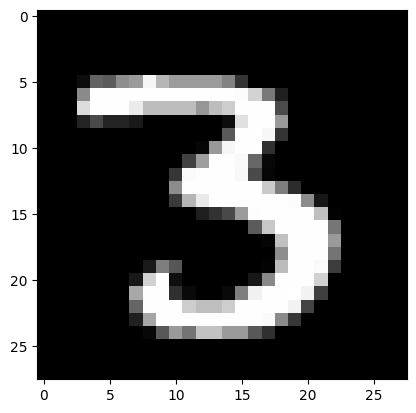

In [11]:
plt.imshow(images[12], cmap='gray')
plt.show()

In [12]:
train_labels[12]

3

In [13]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Input

In [15]:
model = Sequential()

In [16]:
model.add(Input(shape=(28, 28, 1)))

model.add(Conv2D(16, (3,3), activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(16, (3,3), activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dense(10, activation='sigmoid'))

In [17]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 32)         0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 3, 3, 16)          4624      
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 1, 1, 16)         0

In [18]:
model.compile(loss=tf.keras.losses.sparse_categorical_crossentropy,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=[tf.keras.metrics.sparse_categorical_accuracy])

In [19]:
images_valid = images[55000:]
labels_valid = train_labels[55000:]

In [20]:
training = model.fit(images, train_labels, epochs=15, validation_data=(images_valid, labels_valid))

Epoch 1/15
1875/1875 [==============================] - 14s 4ms/step - loss: 1.3380 - sparse_categorical_accuracy: 0.5324 - val_loss: 0.3514 - val_sparse_categorical_accuracy: 0.8954
Epoch 2/15
1875/1875 [==============================] - 6s 3ms/step - loss: 0.2459 - sparse_categorical_accuracy: 0.9249 - val_loss: 0.1265 - val_sparse_categorical_accuracy: 0.9624
Epoch 3/15
1875/1875 [==============================] - 7s 4ms/step - loss: 0.1673 - sparse_categorical_accuracy: 0.9492 - val_loss: 0.0951 - val_sparse_categorical_accuracy: 0.9720
Epoch 4/15
1875/1875 [==============================] - 7s 4ms/step - loss: 0.1373 - sparse_categorical_accuracy: 0.9588 - val_loss: 0.0833 - val_sparse_categorical_accuracy: 0.9732
Epoch 5/15
1875/1875 [==============================] - 7s 4ms/step - loss: 0.1213 - sparse_categorical_accuracy: 0.9630 - val_loss: 0.0876 - val_sparse_categorical_accuracy: 0.9750
Epoch 6/15
1875/1875 [==============================] - 7s 4ms/step - loss: 0.1086 - spar

In [21]:
model.evaluate(test_images, test_labels)

313/313 [==============================] - 1s 3ms/step - loss: 0.0796 - sparse_categorical_accuracy: 0.9784


[0.07958019524812698, 0.9783999919891357]

In [22]:
test_pred = model.predict(test_images)

In [23]:
test_pred[0].shape

(10,)

In [24]:
test_pred = test_pred.argmax(axis=-1)

In [25]:
f1_class = f1_score(test_labels, test_pred,average=None)
print(f1_class)

[0.9795082  0.98637363 0.97629415 0.98124383 0.97603264 0.98087739
 0.98212408 0.97046005 0.9830856  0.9678695 ]


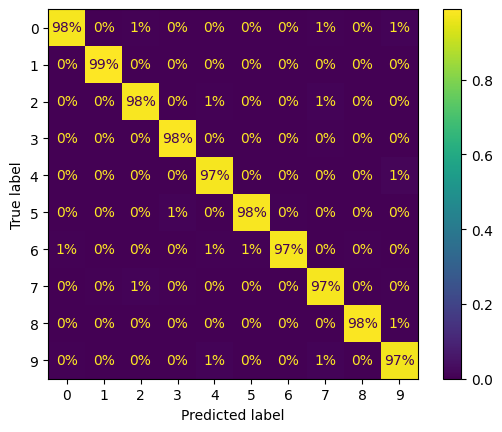

In [26]:
ConfusionMatrixDisplay.from_predictions(test_labels, test_pred, normalize='true', values_format='.0%')